# LSE ST451: Bayesian Machine Learning
## Author: Kostas Kalogeropoulos

## Week 10: Sequential Methods and Data

Topics covered 
 - Kalman filter
 - Example 1: Tracking
 - Example 2: Time varying CAPMs
 - Hidden Markov Models
 - Example 3: Toy example 
 - Example 4: Clickstream Data 

In [3]:
import numpy as np
from numpy.linalg import inv
from scipy.stats import multivariate_normal
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.express as px
from dataclasses import dataclass

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

### Model

We are interested into determining the true position $p$ and velocity $v$ of a vehicle at time $t$ based on meausurements that are subject to random error. The observations are taken over fixed time interval; let $\Delta t$ denote difference between each pair of successive times of measurements. This model can be useful for various tasks such as determining the exact location and velocity at time $t$ and predicting their values at time $t+1$.

We assume the following model about the "true" posistion and velocity: 
$$
\left[\begin{array}{c}p_{t}\\v_{t}\end{array}\right] = \left[\begin{array}{cc}1 & \Delta t\\0 &1\end{array}\right]\left[\begin{array}{c}p_{t-\Delta t}\\v_{t-\Delta t}\end{array}\right] + \left[\begin{array}{c}\frac{1}{2}b \Delta t^2\\b\Delta t\end{array}\right]+\epsilon_t,
$$
where $b$ is a parameter reflecting acceleration, $\epsilon_t\sim N(0,Q)$ with $Q$ taken to be diagonal for simplicity.

Denoting $z=\left[\begin{array}{c}p_{t}\\v_{t}\end{array}\right]$, $A=\left[\begin{array}{cc}1 & \Delta t\\0 &1\end{array}\right]$ and $B=\left[\begin{array}{c}\frac{1}{2}b \Delta t^2\\b\Delta t\end{array}\right]$ and $u_t=1$, we can write the model for the hidden markov process as

$$
z_t = A z_{t-\Delta t} + B u_t +\epsilon_t
$$

Finally model for the noisy measurements $x$ of position and velocity is assumed to be

$$
x_t = z_t + \delta_t 
$$
where $\delta_t \sim N(0,R)$. For the notation in the slides this implies $C=I_2$, $D=0$.



### Prepare for the Kalman filter

In [4]:
p_observations = np.array([4000, 4260, 4550, 4860, 5110])
v_observations = np.array([280, 282, 285, 286, 290])

x= np.c_[p_observations, v_observations]
[n,d] = x.shape

Dt = 1  # Difference in time
b = 2  # Acceleration

# Process / Estimation Errors
sigma_p = 20
sigma_v = 5

# Observation Errors - Uncertainty in the measurement  
omega_p = 25  #
omega_v = 6

#Kalman Filter Matrices needed for the recursions
A = np.array([[1, Dt],
                  [0, 1]])
B = np.array([0.5 * b* Dt ** 2, b*Dt])
u = 1
C = np.eye(d)
D = np.array([0,0])
Q = np.diag([sigma_p**2,sigma_v**2])
R = np.diag([omega_p**2,omega_v**2])
#z_prime = A.dot(X) + B.dot(u)

# Initial Conditions

v0 = 278
z0 = 3995
mu0 = np.array([z0,v0])
Sigma0 = Q

#Objects to store predictions and filtering locations
Mu = np.zeros((n,d))
Mupred = np.zeros((n,d))

### Run the Kalman filter

In [5]:
mu = mu0
Sigma = Sigma0
logL = 0

for i in range(n):
    #observation for time i
    x = np.array([p_observations[i],v_observations[i]])

    #Prediction
    mu = A.dot(mu) + B.T.dot(u)
    Sigma  = A.dot(Sigma).dot(A.T)+Q
    Mupred[i,:] = mu
    
    #Kalman Gain
    S = C.dot(Sigma).dot(C.T) + R
    K = Sigma.dot(C).dot(inv(S))

    #Calculate log likelihood based on the i-th measurement
    M = C.dot(mu.T) +D.T.dot(u) 
    logL = logL + multivariate_normal.logpdf(x, mean=M, cov=S)
    
    # Correction
    mu = mu + K.dot(x- C.dot(mu)- D*u )
    Sigma = (np.identity(d) - K.dot(C)).dot(Sigma)
    Mu[i,:] = mu    
    
print("Kalman Filter log likelihood:\n", logL)

Kalman Filter log likelihood:
 -72.80759787190392


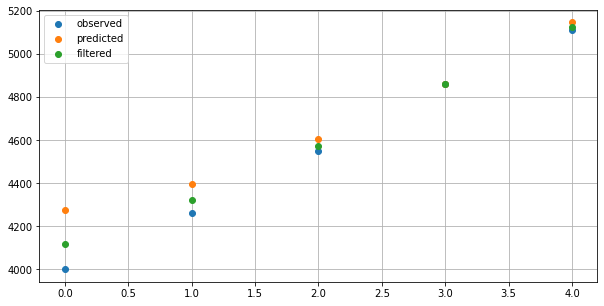

In [6]:
t=range(n)
plt.plot(t,p_observations,'o',label='observed')
plt.plot(t,Mupred[:,0],'o',label='predicted')
plt.plot(t,Mu[:,0],'o',label='filtered')
plt.legend()

### Activity 1 

Simulate 20 points from the following model 
$$
z_t=0.8 z_{t-1}+0.5+\epsilon_t,\;\;\;\;\epsilon_t\sim N(0,1),
$$
$$
x_t= z_t+\delta_t,\;\;\;\;\delta_t\sim N(0,0.5^2),
$$
where t=0,1,...,20 and z_0=0.
Run the Kalman filter on the simulated data and plot the predicted and filtered paths overlaid on the observed data as well as the 'true' z values, i.e. the values you simulated above.

Put your code below:

In [7]:
# Simulate the data
n=20
z = np.zeros(n+1)
x = np.zeros(n+1)
x[0] = z[0]+np.random.randn()
for i in range(n):
    z[i+1] = 0.8*z[i]+0.5+np.random.randn()
    x[i+1] = z[i+1]+0.5*np.random.randn()

In [8]:
# Prepare the Kalman filter

# Kalman filter matrices
A = 0.8
B = 0.5
C = 1
D = 0
u = 1
Q = 1
R = 0.5**2

# Initial Conditions
z0 = 0
mu0 = 0
Sigma0 = Q

#Objects to store predictions and filtering locations
Mu = np.zeros(n+1)
Mupred = np.zeros(n+1)

In [ ]:
mu = mu0
Sigma = Sigma0
logL = 0

for i in range(n):

    #Prediction
    mu = A*mu + B*u
    Sigma  = A*Sigma*A+Q
    Mupred[i] = mu
    
    #Kalman Gain
    S = C*Sigma*C + R
    K = Sigma*C/S

    #Calculate log likelihood based on the i-th measurement
    M = C*mu + D*u 
    logL = logL + multivariate_normal.logpdf(x[i], mean=M, cov=S)
    
    # Correction
    mu = mu + K*(x[i]- C*mu- D*u )
    Sigma = (1 - K*C)*Sigma
    Mu[i] = mu    
    
print("Kalman Filter log likelihood:\n", logL)

In [ ]:
t=range(n+1)
plt.plot(t,z,label='z')
plt.plot(t,x,'o',label='observed')
plt.plot(t,Mupred,label='predicted')
plt.plot(t,Mu,label='filtered')
plt.legend()

### Time varying CAPMs

In [ ]:
stocks = px.data.stocks()
stocks.head()

In [ ]:
# Real price series bundled with plotly.
prices = stocks.copy()
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.set_index("date")
prices.head()

In [ ]:
# Convert the normalised price series to simple returns.
returns = prices.pct_change().dropna()

# Choose one stock and define a simple market proxy from the cross-sectional mean return.
asset_name = "AAPL"
returns["MKT"] = returns.mean(axis=1)
capm = returns[[asset_name, "MKT"]].rename(columns={asset_name: "asset", "MKT": "market"}).copy()
capm.head()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
capm[["asset", "market"]].plot(ax=ax)
ax.set_title("Daily returns: asset and market proxy")
ax.set_ylabel("return")
ax.legend([asset_name, "Market proxy"])
plt.show()

### Activity 2

1. Fit a **static CAPM** using OLS.
2. Then fit a **time-varying CAPM** using the Kalman filter.
3. Plot the filtered estimate of $\beta_t$ through time.
4. Compare the dynamic estimate with the static OLS slope.

Put your code below

In [ ]:
# Static CAPM benchmark
X = np.column_stack([np.ones(len(capm)), capm["market"].values])
y = capm["asset"].values
ols_coef = np.linalg.inv(X.T @ X) @ (X.T @ y)
ols_alpha, ols_beta = ols_coef
print(f"Static CAPM alpha: {ols_alpha:.5f}")
print(f"Static CAPM beta : {ols_beta:.3f}")

In [ ]:
@dataclass
class KalmanOutput:
    m_pred: np.ndarray
    P_pred: np.ndarray
    m_filt: np.ndarray
    P_filt: np.ndarray


def kalman_filter_dynamic_regression(y, x, m0, P0, Q, R):
    """
    Dynamic regression:
        y_t = F_t' theta_t + eps_t,  eps_t ~ N(0, R)
        theta_t = theta_{t-1} + eta_t, eta_t ~ N(0, Q)
    where theta_t = [alpha_t, beta_t]'.
    """
    n = len(y)
    state_dim = len(m0)

    m_pred = np.zeros((n, state_dim))
    P_pred = np.zeros((n, state_dim, state_dim))
    m_filt = np.zeros((n, state_dim))
    P_filt = np.zeros((n, state_dim, state_dim))

    m_prev = m0.copy()
    P_prev = P0.copy()

    for t in range(n):
        # Predict
        a_t = m_prev
        R_t = P_prev + Q

        F_t = np.array([1.0, x[t]])[:, None]   # column vector
        f_t = float((F_t.T @ a_t[:, None]).item())
        Q_t = float((F_t.T @ R_t @ F_t).item() + R)

        # Update
        e_t = y[t] - f_t
        A_t = (R_t @ F_t) / Q_t
        m_t = a_t[:, None] + A_t * e_t
        P_t = R_t - A_t @ F_t.T @ R_t

        m_pred[t] = a_t
        P_pred[t] = R_t
        m_filt[t] = m_t.ravel()
        P_filt[t] = P_t

        m_prev = m_t.ravel()
        P_prev = P_t

    return KalmanOutput(m_pred, P_pred, m_filt, P_filt)

In [ ]:
y = capm["asset"].values
x = capm["market"].values

m0 = np.array([0.0, 1.0])
P0 = np.diag([0.01, 0.25])
Q  = np.diag([1e-6, 5e-5])     # state noise: controls how much alpha/beta can move
R  = 1e-4                      # observation noise

kf_out = kalman_filter_dynamic_regression(y, x, m0, P0, Q, R)
capm["alpha_filt"] = kf_out.m_filt[:, 0]
capm["beta_filt"]  = kf_out.m_filt[:, 1]
capm.head()

In [ ]:
plt.figure(figsize=(11, 4))
plt.plot(capm.index, capm["beta_filt"], label="Filtered dynamic beta")
plt.axhline(ols_beta, linestyle="--", label="Static OLS beta")
plt.title("Time-varying CAPM: filtered beta")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(11, 4))
plt.plot(capm.index, capm["alpha_filt"], label="Filtered dynamic alpha")
plt.axhline(ols_alpha, linestyle="--", label="Static OLS alpha")
plt.title("Time-varying CAPM: filtered alpha")
plt.legend()
plt.show()

### Bob Alice Example of Hidden Markov Models

In [ ]:
states = ('Rainy', 'Sunny')
observations = ('walk', 'shop', 'clean')
pi = np.array([0.6, 0.4])  #initial probability 
A = np.array([[0.7, 0.3],[0.4, 0.6]]) #Transmission probability 
B = np.array([[0.1, 0.4, 0.5],[0.6, 0.3, 0.1]]) #Emission probability
bob_says = np.array([0, 2, 1, 1, 2, 0, 1,2,1,0,0,2,1])
print(bob_says)

### Forward Algorithm

In [ ]:
def forward(obs_seq, pi, A, B):
    T = len(obs_seq)
    N = A.shape[0]
    alpha = np.zeros((T, N))
    alpha[0] = pi*B[:,obs_seq[0]]
    for t in range(1, T):
        alpha[t] = np.inner(alpha[t-1],A) * B[:, obs_seq[t]]
    return alpha

def likelihood(alpha):
    # returns log P(Y  \mid  model)
    # using the forward part of the forward-backward algorithm
    return  alpha[-1].sum()

In [ ]:
alpha = forward(bob_says, pi, A, B)
print(alpha)

In [ ]:
likelihood(alpha)

### Forward Backward Algorithm

In [ ]:
def backward(obs_seq, A, B):
    N = A.shape[0]
    T = len(obs_seq)

    beta = np.zeros((N,T))
    beta[:,-1:] = 1

    for t in reversed(range(T-1)):
        for n in range(N):
            beta[n,t] = np.sum(beta[:,t+1] * A[n,:] * B[:, obs_seq[t+1]])

    return beta

def fb(alpha, beta):
    obs_prob = likelihood(alpha)
    gamma = np.multiply(alpha,beta.T)
    gamma /= gamma.sum(axis=1, keepdims=True)
    return gamma

In [ ]:
beta=backward(bob_says, A, B)
gamma=fb(alpha, beta)
print('beta',beta.T)
print('gamma',gamma)

In [ ]:
def viterbi(obs_seq,pi, A, B):
    # returns the most likely state sequence given observed sequence x
    # using the Viterbi algorithm
    T = len(obs_seq)
    N = A.shape[0]
    delta = np.zeros((T, N))
    psi = np.zeros((T, N))
    delta[0] = pi*B[:,obs_seq[0]]
    for t in range(1, T):
        for j in range(N):
            delta[t,j] = np.max(delta[t-1]*A[:,j]) * B[j, obs_seq[t]]
            psi[t,j] = np.argmax(delta[t-1]*A[:,j])

    # backtrack
    states = np.zeros(T, dtype=np.int32)
    states[T-1] = np.argmax(delta[T-1])
    for t in range(T-2, -1, -1):
        states[t] = psi[t+1, states[t+1]]
    return states

In [ ]:
alice_infers=viterbi(bob_says, pi, A, B)
names = ['Bob says','Alice infers']
BS = list(map(lambda y: observations[y], bob_says))
AI = list(map(lambda s: states[s], alice_infers))

best_path = pd.DataFrame(np.column_stack([BS,AI]),columns=names)
best_path
#print("Bob says:", ", ",list(map(lambda y: observations[y], bob_says)))
#print("Alice infers:", ", ", list(map(lambda s: states[s], alice_infers)))

### Clickstream modelling via a Hidden Markov Model

We observe what a user **does** but we care about their latent **intent**. A simple HMM separates these two layers:

- hidden states: `Browsing`, `Considering`, `HighIntent`
- observed actions: `home`, `search`, `product`, `cart`, `checkout`

This is a good bridge to machine learning because it is a **generative sequence model**: it specifies how a latent state sequence generates observable actions.

In [ ]:
states = ["Browsing", "Considering", "HighIntent"]
actions = ["home", "search", "product", "cart", "checkout"]

state_to_idx = {s: i for i, s in enumerate(states)}
action_to_idx = {a: i for i, a in enumerate(actions)}

# Transition probabilities
A = np.array([
    [0.70, 0.25, 0.05],
    [0.20, 0.60, 0.20],
    [0.05, 0.30, 0.65],
])

# Emission probabilities
B = np.array([
    [0.40, 0.30, 0.20, 0.08, 0.02],
    [0.10, 0.20, 0.45, 0.20, 0.05],
    [0.02, 0.08, 0.20, 0.35, 0.35],
])

pi = np.array([0.85, 0.10, 0.05])

In [ ]:
def simulate_hmm_session(T=20, A=A, B=B, pi=pi):
    z = np.zeros(T, dtype=int)
    y = np.zeros(T, dtype=int)

    z[0] = np.random.choice(len(states), p=pi)
    y[0] = np.random.choice(len(actions), p=B[z[0]])

    for t in range(1, T):
        z[t] = np.random.choice(len(states), p=A[z[t - 1]])
        y[t] = np.random.choice(len(actions), p=B[z[t]])
    return z, y

z, y = simulate_hmm_session(T=25)
clickstream = pd.DataFrame({
    "t": np.arange(1, len(y) + 1),
    "action": [actions[i] for i in y],
    "true_state": [states[i] for i in z],
})
clickstream.head(10)

### Activity 3

1. Treat the sequence of click actions as the observed data.
2. Implement the **forward algorithm** to compute filtering probabilities.
3. Implement **forward-backward** to obtain smoothed probabilities.
4. Compare the posterior state probabilities with the true latent states from the simulation.

Put your code below:

In [ ]:
def forward_algorithm(obs, A, B, pi):
    T = len(obs)
    K = A.shape[0]
    alpha = np.zeros((T, K))
    scales = np.zeros(T)

    alpha[0] = pi * B[:, obs[0]]
    scales[0] = alpha[0].sum()
    alpha[0] /= scales[0]

    for t in range(1, T):
        alpha[t] = (alpha[t - 1] @ A) * B[:, obs[t]]
        scales[t] = alpha[t].sum()
        alpha[t] /= scales[t]

    loglik = np.sum(np.log(scales))
    return alpha, scales, loglik


def backward_algorithm(obs, A, B, scales):
    T = len(obs)
    K = A.shape[0]
    beta = np.zeros((T, K))
    beta[-1] = 1.0

    for t in range(T - 2, -1, -1):
        beta[t] = A @ (B[:, obs[t + 1]] * beta[t + 1])
        beta[t] /= scales[t + 1]

    return beta


def forward_backward(obs, A, B, pi):
    alpha, scales, loglik = forward_algorithm(obs, A, B, pi)
    beta = backward_algorithm(obs, A, B, scales)
    gamma = alpha * beta
    gamma /= gamma.sum(axis=1, keepdims=True)
    return alpha, beta, gamma, loglik

In [ ]:
obs = np.array([action_to_idx[a] for a in clickstream["action"]])
alpha, beta, gamma, loglik = forward_backward(obs, A, B, pi)
print(f"Log-likelihood of session: {loglik:.3f}")

posterior = pd.DataFrame(gamma, columns=[f"P({s})" for s in states])
posterior.insert(0, "action", clickstream["action"].values)
posterior.insert(0, "t", clickstream["t"].values)
posterior.head(10)

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
for s in states:
    ax.plot(clickstream["t"], posterior[f"P({s})"], label=s)
ax.set_xlabel("Time step")
ax.set_ylabel("Posterior probability")
ax.set_title("Smoothed state probabilities for the clickstream session")
ax.legend()
plt.show()

In [ ]:
most_likely = gamma.argmax(axis=1)
result = clickstream.copy()
result["inferred_state"] = [states[i] for i in most_likely]
result.head(15)